# LiDAR Trail Audit Tool — v8

Automated MTB trail difficulty auditing against the NZ Mountain Bike Trail Design and Construction Guidelines (Recreation Aotearoa 2022)




In [11]:
# Imports & configuration 


import os, io, json, math, base64
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import requests
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import folium
import plotly.graph_objects as go
from pyproj import Transformer
from shapely.geometry import LineString
from scipy.ndimage import uniform_filter1d
import os, io, base64
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import os, io, base64
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

#Add an input function for these later on
trail_name   = "Askins"
kml_path     = "askins.kml"      
stated_grade = 4                 

#Linz Data Service API
API_KEY = os.environ.get("LINZ_API_KEY", "24d5daf2151847f7b7db497b10ea8712")

LAYER_DEM_NATIONAL   = 121859    #Nation wide dem.
LAYER_AERIAL         = 123118    # aerial imagery tiles (editor basemap)
ELEVATION_LAYER = LAYER_DEM_NATIONAL
SIDESLOPE_LAYER = LAYER_DEM_NATIONAL

#Replaces google drive
CACHE_DIR, OUTPUT_DIR = "./cache", "./output"
os.makedirs(CACHE_DIR,  exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# projections
to_nztm  = Transformer.from_crs("EPSG:4326", "EPSG:2193", always_xy=True)
to_wgs84 = Transformer.from_crs("EPSG:2193", "EPSG:4326", always_xy=True)

#Ensures the user has a KML file attached.
if not os.path.exists(kml_path):
    raise FileNotFoundError(
        f"Can't find '{kml_path}'.\nWorking directory: {os.getcwd()}\n"
        "Put the KML next to this notebook, or set kml_path to a full path.")

#Confirms paths before the program runs.
print(f"Trail   : {trail_name} (stated grade {stated_grade})")
print(f"KML     : {os.path.abspath(kml_path)}")
print(f"Cache   : {os.path.abspath(CACHE_DIR)}")
print(f"Output  : {os.path.abspath(OUTPUT_DIR)}")


Trail   : Askins (stated grade 4)
KML     : c:\Users\Shea\Downloads\askins.kml
Cache   : c:\Users\Shea\Downloads\cache
Output  : c:\Users\Shea\Downloads\output


In [12]:
#  Grading thresholds 
# NZ MTB Trail Design & Construction Guidelines, 2nd ed. August 2022,


# (grade, average gradient max %, absolute gradient max %, out-of-spec tolerance %)
gradient_grades = [
    (1,  6.1,  7.0,   2),
    (2,  8.8, 14.1,   5),
    (3, 10.5, 19.3,  10),
    (4, 17.5, 27.0,  20),
    (5, 24.9, 36.0,  20),
    (6, float("inf"), float("inf"), 100),
]

# (grade, minimum turn radius m, out-of-spec tolerance %)
radius_grades = [
    (1, 5.0,   2),
    (2, 4.0,   5),
    (3, 2.5,  10),
    (4, 2.0,  20),
    (5, 1.5,  20),
    (6, 1.0, 100),
]

grade_colours = {
    1: "Green (Easiest)",     2: "Green (Easy)",
    3: "Light Blue (Intermediate)", 4: "Dark Blue (Advanced)",
    5: "Black (Expert)",      6: "Double Black (Extreme)",
}

GRADIENT_ABS_MAX = {g: m for g, _, m, _ in gradient_grades}
RADIUS_MIN       = {g: r for g, r, _    in radius_grades}


print("Thresholds loaded.")


Thresholds loaded.


### Note on the out of spec rule

According to the guidlines, there are two conditions for out of spec sections. 2% for Grade 1, 5% for Grade 2, 10% for Grade 3, 20% for Grade 4+.
Out of spec sectios must be no more than one grade harder than the trails stated grade.

This change has been updated from the previous version.



In [13]:
#Load KML 
#Changed to work for vs code, rather than google colab.

from pykml import parser

with open(kml_path, "rb") as f:
    root = parser.parse(f).getroot()

nodes = root.findall(".//{http://www.opengis.net/kml/2.2}coordinates")
if not nodes:
    raise ValueError(f"No <coordinates> element in {kml_path}")

points_wgs84 = []
for pt in nodes[0].text.strip().split():
    lon, lat, *_ = pt.split(",")
    points_wgs84.append((float(lon), float(lat)))

print(f"Loaded {len(points_wgs84)} points from {kml_path}")
print(f"First point: {points_wgs84[0]}")


Loaded 112 points from askins.kml
First point: (172.64053, -43.59534)


## Trail line editor

Trailforks Kml data only has 4m of horizontal GPS error, which is why the trail line is very accurate. This section of code lets you manually move the trail line to its real position.



In [14]:
# -- DEM overlays for the editor 
# The DEM I have used was downloaded from the LINZ website. 
# This may not be accessable for the average user, so I will have to figure out another way around this. 

DEM_TIF   = r"C:\Users\Shea\GIS_Work\askins_dem.tif"   # 1 m bare-earth DEM, EPSG:2193
VERT_EXAG = 1.5                                        # hillshade vertical exaggeration


def _png_data_uri(rgba):
    buf = io.BytesIO()
    plt.imsave(buf, rgba, format="png")
    buf.seek(0)
    return "data:image/png;base64," + base64.b64encode(buf.read()).decode("ascii")


def _hillshade_from_dem(path):
    """-> (data-URI PNG, WGS84 bounds, (zmin, zmax)).

    Rendered on the DEM's native metric grid, then warped to WGS84 so it lines up
    with the map. Bounds come from the warped transform, so image and placement
    can't drift apart.
    """
    import rasterio
    from rasterio.transform import array_bounds
    from rasterio.warp import calculate_default_transform, reproject, Resampling

    with rasterio.open(path) as src:
        Z = src.read(1, masked=True).filled(np.nan).astype(float)
        src_crs, src_t, src_bounds = src.crs, src.transform, src.bounds

    if np.isnan(Z).any():                        # nearest-fill gaps so shading is clean
        from scipy.ndimage import distance_transform_edt
        idx = distance_transform_edt(np.isnan(Z), return_distances=False,
                                    return_indices=True)
        Z = Z[tuple(idx)]

    h, w = Z.shape
    shade = LightSource(azdeg=315, altdeg=45).hillshade(
        Z, vert_exag=VERT_EXAG, dx=abs(src_t.a), dy=abs(src_t.e))
    rgba = plt.cm.gray(shade)                    # <- plt.cm.terrain(...) for elevation colour

    dst_crs = "EPSG:4326"
    dst_t, dw, dh = calculate_default_transform(src_crs, dst_crs, w, h, *src_bounds)
    src_rgba = np.ascontiguousarray(np.moveaxis((rgba * 255).astype(np.uint8), 2, 0))
    dst_rgba = np.zeros((4, dh, dw), np.uint8)
    reproject(src_rgba, dst_rgba, src_transform=src_t, src_crs=src_crs,
            dst_transform=dst_t, dst_crs=dst_crs, resampling=Resampling.bilinear)

    west, south, east, north = array_bounds(dh, dw, dst_t)
    return (_png_data_uri(np.moveaxis(dst_rgba, 0, 2)),
            ((south, west), (north, east)),
            (float(Z.min()), float(Z.max())))


# This cell builds the hillshade only. The editor cell below still has optional
# guards for the elevation/slope/tinted overlays, so they're initialised to None
# here -- otherwise those guards raise NameError.
HILLSHADE_URI = ELEVATION_URI = SLOPE_URI = TINTED_URI = DEM_BOUNDS = None
if os.path.exists(DEM_TIF):
    try:
        HILLSHADE_URI, DEM_BOUNDS, _zr = _hillshade_from_dem(DEM_TIF)
        print(f"DEM hillshade built from {DEM_TIF}")
        print(f"  WGS84 bounds (S,W)-(N,E): {DEM_BOUNDS}")
        print(f"  Elevation {_zr[0]:.0f}-{_zr[1]:.0f} m")
        print("  Editor layers: LINZ aerial (base) + hillshade -- toggle top-right.")
    except Exception as e:
        print(f"Could not build hillshade from {DEM_TIF}: {e}")
        print("The editor will fall back to the aerial basemap.")
else:
    print(f"No DEM at {DEM_TIF} -- editor will use the aerial basemap only.")


DEM hillshade built from C:\Users\Shea\GIS_Work\askins_dem.tif
  WGS84 bounds (S,W)-(N,E): ((-43.59793287201566, 172.6312889697974), (-43.59141633500591, 172.64321716383947))
  Elevation 20-354 m
  Editor layers: LINZ aerial (base) + hillshade -- toggle top-right.


In [15]:
# -- Interactive trail line editor -----------------------------------
# Draggable markers reshape the line; add/delete happen by clicking the map.
#
# KEY FIX (v8): drags are now caught with Marker.on_move(). The old code used
# marker.observe(names="location"), but ipyleaflet's frontend never syncs the
# location trait back on a drag -- it sends a separate "move" event -- so the
# observer never fired and the line never followed the markers. Delete now also
# goes through the map-click path (reliable) instead of marker.on_click.

from ipyleaflet import (Map, TileLayer, ImageOverlay, LayersControl,
                        Marker, Polyline, WidgetControl)
from ipywidgets import Button, HBox, HTML, ToggleButtons

AERIAL_URL = (f"https://tiles-cdn.koordinates.com/services;key={API_KEY}"
              f"/tiles/v4/layer={LAYER_AERIAL},style=auto/EPSG:3857/{{z}}/{{x}}/{{y}}.png")

SAVE_PATH = os.path.join(OUTPUT_DIR, f"{trail_name}_centreline_corrected.geojson")

# Resume from a previous session if one was saved
if os.path.exists(SAVE_PATH):
    with open(SAVE_PATH) as f:
        corrected_coords = [list(c) for c in json.load(f)["geometry"]["coordinates"]]
    print(f"Resumed {len(corrected_coords)} vertices from {SAVE_PATH}")
else:
    corrected_coords = [[lon, lat] for lon, lat in points_wgs84]
    print(f"Starting from the KML line: {len(corrected_coords)} vertices")

_clat = sum(c[1] for c in corrected_coords) / len(corrected_coords)
_clon = sum(c[0] for c in corrected_coords) / len(corrected_coords)

# The overlay URIs are built by the DEM cell above. Default them here so this cell
# runs standalone too -- without this, a fresh kernel that skipped the DEM cell
# raises "NameError: name 'ELEVATION_URI' is not defined" at the guards below.
# globals().get() keeps whatever the DEM cell already set rather than clobbering it.
HILLSHADE_URI = globals().get("HILLSHADE_URI")
ELEVATION_URI = globals().get("ELEVATION_URI")
SLOPE_URI     = globals().get("SLOPE_URI")
TINTED_URI    = globals().get("TINTED_URI")
DEM_BOUNDS    = globals().get("DEM_BOUNDS")

# Layer stack, bottom -> top: aerial (context/fallback), DEM elevation,
# elevation+relief, slope, hillshade (opaque). The grey hillshade is the default
# editing surface -- it shows the real tread's bench cut, which the aerial hides
# under canopy. Uncheck layers in the control (top-right) to reveal the ones below.
_base = TileLayer(url=AERIAL_URL, name="LINZ aerial", max_zoom=22)
editor_map = Map(center=(_clat, _clon), zoom=16, scroll_wheel_zoom=True, layers=[_base])

if ELEVATION_URI:
    editor_map.add(ImageOverlay(url=ELEVATION_URI, bounds=DEM_BOUNDS,
                                name="DEM elevation", opacity=1.0))
if SLOPE_URI:
    editor_map.add(ImageOverlay(url=SLOPE_URI, bounds=DEM_BOUNDS,
                                name="LiDAR slope", opacity=0.85))
if TINTED_URI:
    editor_map.add(ImageOverlay(url=TINTED_URI, bounds=DEM_BOUNDS,
                                name="Elevation + relief", opacity=1.0))
if HILLSHADE_URI:
    editor_map.add(ImageOverlay(url=HILLSHADE_URI, bounds=DEM_BOUNDS,
                                name="LiDAR hillshade", opacity=1.0))
else:
    print("No DEM hillshade -- run the DEM overlay cell above; using aerial only.")

# UI widgets are created up front so the handlers below can reference them.
_mode   = ToggleButtons(options=["Drag only", "Add point", "Delete point"],
                        value="Drag only", button_style="")
_status = HTML()
_save_btn  = Button(description="Save", button_style="success")
_reset_btn = Button(description="Reset to KML", button_style="warning")

# Live counters: if these stay at 0 while you drag/click, the browser isn't
# reaching the kernel at all (an environment problem, not this code).
_ev = {"move": 0, "click": 0}

_line = Polyline(locations=[[lat, lon] for lon, lat in corrected_coords],
                 color="#ff00ff", weight=3, fill=False)
_markers = []


def _redraw():
    _line.locations = [[lat, lon] for lon, lat in corrected_coords]
    _status.value = (f"<b>{len(corrected_coords)}</b> verts &nbsp;|&nbsp; "
                     f"mode <b>{_mode.value}</b> &nbsp;|&nbsp; "
                     f"drags {_ev['move']} &middot; clicks {_ev['click']}")


def _on_move_factory(marker):
    """Resolve the marker's current index at drag time (survives inserts/deletes)."""
    def _cb(**content):
        loc = content.get("location")
        if not loc:
            return
        try:
            i = _markers.index(marker)
        except ValueError:
            return
        _ev["move"] += 1
        lat, lon = loc
        corrected_coords[i] = [lon, lat]
        _redraw()
    return _cb


def _add_marker(lat, lon, index=None):
    mk = Marker(location=(lat, lon), draggable=True)
    mk.on_move(_on_move_factory(mk))          # <-- the fix: on_move, not observe()
    if index is None:
        _markers.append(mk)
    else:
        _markers.insert(index, mk)
    editor_map.add(mk)
    return mk


for _lon, _lat in corrected_coords:
    _add_marker(_lat, _lon)

editor_map.add(_line)
editor_map.add(LayersControl(position="topright"))


# ---- metre-accurate helpers (a degree of longitude at -43.6 is ~0.72 of a
# ---- degree of latitude, so plain degree distances would be skewed) ----
def _local_xy(lat, lon):
    kx = math.cos(math.radians(lat)) * 111_320.0
    return lon * kx, lat * 110_574.0, kx


def _insert_index(lat, lon):
    """Index at which to insert a clicked point: after the nearest segment."""
    px, py, kx = _local_xy(lat, lon)
    best_i, best_d = 0, float("inf")
    for i in range(len(corrected_coords) - 1):
        ax, ay = corrected_coords[i][0] * kx,     corrected_coords[i][1] * 110_574.0
        bx, by = corrected_coords[i + 1][0] * kx, corrected_coords[i + 1][1] * 110_574.0
        dx, dy = bx - ax, by - ay
        seg2 = dx * dx + dy * dy
        t = 0.0 if seg2 == 0 else max(0.0, min(1.0, ((px - ax) * dx + (py - ay) * dy) / seg2))
        d = math.hypot(px - (ax + t * dx), py - (ay + t * dy))
        if d < best_d:
            best_d, best_i = d, i
    return best_i + 1


def _nearest_vertex(lat, lon):
    """Index of the closest existing vertex to a click, and its distance in metres."""
    px, py, kx = _local_xy(lat, lon)
    best_i, best_d = 0, float("inf")
    for i, (vlon, vlat) in enumerate(corrected_coords):
        d = math.hypot(px - vlon * kx, py - vlat * 110_574.0)
        if d < best_d:
            best_d, best_i = d, i
    return best_i, best_d


def _on_map_click(**kwargs):
    if kwargs.get("type") != "click":
        return
    lat, lon = kwargs["coordinates"]
    _ev["click"] += 1
    if _mode.value == "Add point":
        idx = _insert_index(lat, lon)
        corrected_coords.insert(idx, [lon, lat])
        _add_marker(lat, lon, index=idx)
        _redraw()
    elif _mode.value == "Delete point":
        if len(corrected_coords) <= 2:
            _status.value = "Need at least 2 vertices."
            return
        i, d = _nearest_vertex(lat, lon)
        if d > 15:                       # ignore clicks far from any vertex
            _redraw()
            return
        corrected_coords.pop(i)
        editor_map.remove(_markers.pop(i))
        _redraw()
    else:
        _redraw()                        # keep the counter display live in Drag mode


editor_map.on_interaction(_on_map_click)


def _on_save(b):
    feature = {
        "type": "Feature",
        "properties": {"name": trail_name, "stated_grade": stated_grade,
                       "source": "manually corrected centreline",
                       "vertices": len(corrected_coords)},
        "geometry": {"type": "LineString",
                     "coordinates": [[float(a), float(b_)] for a, b_ in corrected_coords]},
    }
    with open(SAVE_PATH, "w") as f:
        json.dump(feature, f, indent=1)
    _status.value = f"Saved {len(corrected_coords)} vertices -> {SAVE_PATH}"


def _on_reset(b):
    global corrected_coords
    for mk in list(_markers):
        editor_map.remove(mk)
    _markers.clear()
    corrected_coords = [[lon, lat] for lon, lat in points_wgs84]
    for lon, lat in corrected_coords:
        _add_marker(lat, lon)
    _redraw()
    _status.value = f"Reset to the original KML ({len(corrected_coords)} vertices)."


_save_btn.on_click(_on_save)
_reset_btn.on_click(_on_reset)
_mode.observe(lambda c: _redraw(), names="value")

editor_map.add(WidgetControl(
    widget=HBox([_mode, _save_btn, _reset_btn, _status]), position="bottomleft"))
_redraw()

print("Drag vertices onto the real track. In 'Add point' mode click the map to "
      "insert a vertex; in 'Delete point' mode click near a vertex to remove it.")
print("Watch the 'drags'/'clicks' counters in the status bar -- if they move, the "
      "editor is talking to the kernel. Save writes GeoJSON you can open in QGIS.")
editor_map


Resumed 112 vertices from ./output\Askins_centreline_corrected.geojson
Drag vertices onto the real track. In 'Add point' mode click the map to insert a vertex; in 'Delete point' mode click near a vertex to remove it.
Watch the 'drags'/'clicks' counters in the status bar -- if they move, the editor is talking to the kernel. Save writes GeoJSON you can open in QGIS.


Map(center=[-43.59315576095532, 172.63528764040643], controls=(ZoomControl(options=['position', 'zoom_in_text'…

In [16]:
# ── Apply the edited line ──────────────────────────────────────────
# Prefers the saved file, so a kernel restart doesn't lose your edits.

if os.path.exists(SAVE_PATH):
    with open(SAVE_PATH) as f:
        saved = json.load(f)["geometry"]["coordinates"]
    points_wgs84 = [(float(a), float(b)) for a, b in saved]
    print(f"Applied SAVED corrected line: {len(points_wgs84)} points ({SAVE_PATH})")
elif "corrected_coords" in globals():
    points_wgs84 = [(float(a), float(b)) for a, b in corrected_coords]
    print(f"Applied IN-MEMORY edited line: {len(points_wgs84)} points (not saved yet)")
else:
    print(f"No edits — using the original KML line: {len(points_wgs84)} points")

print(f"First point: {points_wgs84[0]}")


Applied SAVED corrected line: 112 points (./output\Askins_centreline_corrected.geojson)
First point: (172.64053, -43.59534)


In [ ]:
#Reproject to NZTM2000 and interpolate to 1 m 
# Interpolation doesn't add accuracy — it only gives the gradient and radius
#Probs will remove the interpolation part. Although it does add points between the points.

points_nztm = [to_nztm.transform(lon, lat) for lon, lat in points_wgs84]

line = LineString(points_nztm)
points_nztm_dense = [(p.x, p.y) for p in
                     (line.interpolate(d) for d in np.arange(0, line.length, 1.0))]
points_wgs84_dense = [to_wgs84.transform(x, y) for x, y in points_nztm_dense]

print(f"Trail length : {line.length:.1f} m")
print(f"{len(points_nztm)} source points -> {len(points_nztm_dense)} at 1 m spacing")


Trail length : 2110.6 m
112 source points -> 2111 at 1 m spacing


In [ ]:
# Fetch elevations from LINZ API.
# - First run: fetches all ~2,100 elevations and saves them locally
# - Re-run same trail: loads from cache instantly (no API wait)
# - Edit the trail line using the tool above: cache auto-invalidates and re-fetches
# - This still need some work as I have taken techniques from online that I dont quite fully understand, and there is room for improvement also.
import hashlib

def fetch_elevation(args, layer=None):
    lon, lat = args
    layer = layer or ELEVATION_LAYER
    try:
        r = requests.get("https://data.linz.govt.nz/services/query/v1/raster.json",
                         params={"key": API_KEY, "layer": layer, "x": lon, "y": lat},
                         timeout=20)
        bands = r.json()["rasterQuery"]["layers"][str(layer)]["bands"]
        return float(bands[0]["value"]) if bands and bands[0] else None
    except Exception:
        return None


line_hash = hashlib.md5(
    json.dumps([[round(a, 7), round(b, 7)] for a, b in points_wgs84]).encode()
).hexdigest()[:10]
CACHE_FILE = os.path.join(CACHE_DIR, f"{trail_name}_elev_{ELEVATION_LAYER}_{line_hash}.json")

if os.path.exists(CACHE_FILE):
    print(f"Loading cached elevations ({os.path.basename(CACHE_FILE)})...")
    with open(CACHE_FILE) as f:
        elevations_dense = json.load(f)
else:
    print(f"Fetching {len(points_wgs84_dense)} elevations from layer {ELEVATION_LAYER}...")
    with ThreadPoolExecutor(max_workers=16) as ex:
        elevations_dense = list(ex.map(fetch_elevation, points_wgs84_dense))
    with open(CACHE_FILE, "w") as f:
        json.dump(elevations_dense, f)
    print(f"Cached to {CACHE_FILE}")

failed = elevations_dense.count(None)
print(f"Got {len(elevations_dense)} elevations, {failed} failed")
if failed / len(elevations_dense) > 0.05:
    print("WARNING: >5% of queries failed — check the API key and layer coverage "
          "before trusting the grade.")

keep = [i for i, e in enumerate(elevations_dense) if e is not None]
points_nztm_dense  = [points_nztm_dense[i]  for i in keep]
points_wgs84_dense = [points_wgs84_dense[i] for i in keep]
elevations_dense   = [elevations_dense[i]   for i in keep]


Loading cached elevations (Askins_elev_121859_45abbc4757.json)...
Got 2111 elevations, 0 failed


In [ ]:
#  Gradient 

gradients_dense = []
for i in range(1, len(points_nztm_dense)):
    x1, y1 = points_nztm_dense[i - 1]
    x2, y2 = points_nztm_dense[i]
    run = math.hypot(x2 - x1, y2 - y1)
    rise = elevations_dense[i] - elevations_dense[i - 1]
    gradients_dense.append((rise / run * 100) if run > 0 else 0.0)

# 50 m smoothing window, so that it is the sustained gradient that is measured.
window = 50
smoothed_dense = np.convolve(gradients_dense, np.ones(window) / window, mode="valid")

print(f"Average gradient : {np.mean(smoothed_dense):+.1f}%")
print(f"Max descent      : {np.min(smoothed_dense):+.1f}%")
print(f"Max ascent       : {np.max(smoothed_dense):+.1f}%")


Average gradient : -8.9%
Max descent      : -27.0%
Max ascent       : +14.5%


In [ ]:
# Assigning a grade based on the gradient.

avg_gradient   = abs(np.mean(smoothed_dense))
worst_gradient = float(np.max(np.abs(smoothed_dense)))
n = len(smoothed_dense)

gradient_grade, gradient_reason = 6, "exceeds all defined limits"

for grade, avg_limit, abs_limit, tolerance in gradient_grades:
    pct_out = len([g for g in smoothed_dense if abs(g) > abs_limit]) / n * 100
    one_harder = GRADIENT_ABS_MAX.get(grade + 1, float("inf"))
    if avg_gradient <= avg_limit and pct_out <= tolerance and worst_gradient <= one_harder:
        cap = "no cap" if math.isinf(one_harder) else f"cap {one_harder}%"
        gradient_grade = grade
        gradient_reason = (f"avg {avg_gradient:.1f}% (limit {avg_limit}%), "
                           f"{pct_out:.1f}% over {abs_limit}% (tolerance {tolerance}%), "
                           f"steepest {worst_gradient:.1f}% ({cap})")
        break

print(f"Gradient grade {gradient_grade} — {gradient_reason}")


Gradient grade 3 — avg 8.9% (limit 10.5%), 3.3% over 19.3% (tolerance 10%), steepest 27.0% (cap 27.0%)


In [ ]:
# ── Corner radius ──────────────────────────────────────────────────

def circumradius(p1, p2, p3):
    """Radius of the circle through three points. inf when collinear."""
    (ax, ay), (bx, by), (cx, cy) = p1, p2, p3
    a, b, c = math.dist(p1, p2), math.dist(p2, p3), math.dist(p1, p3)
    area = abs((ax * (by - cy) + bx * (cy - ay) + cx * (ay - by)) / 2)
    return float("inf") if area == 0 else (a * b * c) / (4 * area)




radii_sampled = [
    circumradius(points_nztm_dense[i - step], points_nztm_dense[i], points_nztm_dense[i + step])
    for i in range(step, len(points_nztm_dense) - step)
]

# Straight sections give infinite radius, thus the average would be useless. 
# Instead I use percentiles to focus on the tightest corners, which are what actualy determine the trail grade.
finite = np.array([r for r in radii_sampled if math.isfinite(r)])
stated_min = RADIUS_MIN[stated_grade]
under = len([r for r in radii_sampled if r < stated_min]) / len(radii_sampled) * 100

print(f"Sampled {len(radii_sampled)} positions ({len(radii_sampled) - len(finite)} straight)")
print(f"Tightest radius     : {min(radii_sampled):.1f} m")
print(f"5th percentile      : {np.percentile(finite, 5):.1f} m")
print(f"25th percentile     : {np.percentile(finite, 25):.1f} m")
print(f"Under Grade {stated_grade} min ({stated_min} m): {under:.1f}% of trail")
print("\nNOTE: with the raw Trailforks line these numbers carry ~4 m of horizontal "
      "GPS error.\nCorrect the centreline in the editor above before quoting them.")


Sampled 2101 positions (224 straight)
Tightest radius     : 2.6 m
5th percentile      : 6.2 m
25th percentile     : 24.8 m
Under Grade 4 min (2.0 m): 0.0% of trail

NOTE: with the raw Trailforks line these numbers carry ~4 m of horizontal GPS error.
Correct the centreline in the editor above before quoting them.


In [ ]:
# Grade by corner radius

radii_filtered = [r for r in radii_sampled if r >= 1.0]   # <1 m treated as artefact
tightest = min(radii_filtered)

radius_grade, radius_reason = 6, "tighter than all defined limits"

for grade, min_radius, tolerance in radius_grades:
    pct_out = len([r for r in radii_filtered if r < min_radius]) / len(radii_filtered) * 100
    one_harder = RADIUS_MIN.get(grade + 1, 0.0)
    if pct_out <= tolerance and tightest >= one_harder:
        radius_grade = grade
        radius_reason = (f"{pct_out:.1f}% under {min_radius} m (tolerance {tolerance}%), "
                         f"tightest {tightest:.1f} m (floor {one_harder} m)")
        break

print(f"Corner grade {radius_grade} — {radius_reason}")


Corner grade 2 — 0.6% under 4.0 m (tolerance 5%), tightest 2.6 m (floor 2.5 m)


In [ ]:
# Overall trail grade 
overall_grade = max(gradient_grade, radius_grade)

bar = "=" * 60
print(bar)
print(f"  {trail_name} — Trail Audit")
print(bar)
print(f"  Stated grade    : {stated_grade}  ({grade_colours[stated_grade]})")
print(f"  Gradient grade  : {gradient_grade}")
print(f"    {gradient_reason}")
print(f"  Corner grade    : {radius_grade}")
print(f"    {radius_reason}")
print(bar)
print(f"  MEASURED GRADE  : {overall_grade}  ({grade_colours[overall_grade]})")
if overall_grade > stated_grade:
    print(f"  MISMATCH: measured HARDER than signposted ({overall_grade} vs "
          f"{stated_grade}) — under-graded")
elif overall_grade < stated_grade:
    print(f"  MISMATCH: measured EASIER than signposted ({overall_grade} vs "
          f"{stated_grade}) — over-graded")
else:
    print("  Signposted grade matches measured grade.")
print(bar)


  Askins — Trail Audit
  Stated grade    : 4  (Dark Blue (Advanced))
  Gradient grade  : 3
    avg 8.9% (limit 10.5%), 3.3% over 19.3% (tolerance 10%), steepest 27.0% (cap 27.0%)
  Corner grade    : 2
    0.6% under 4.0 m (tolerance 5%), tightest 2.6 m (floor 2.5 m)
  MEASURED GRADE  : 3  (Light Blue (Intermediate))
  MISMATCH: measured EASIER than signposted (3 vs 4) — over-graded


In [ ]:
# ── Corner detection ───────────────────────────────────────────────

def bearing(p1, p2):
    return math.atan2(p2[1] - p1[1], p2[0] - p1[0])


def find_apex(points, start, end):
    """Index of the sharpest bearing change in a slice — the corner apex."""
    max_change, apex = 0.0, (start + end) // 2
    for i in range(start + 1, end - 1):
        change = abs(bearing(points[i], points[i + 1]) - bearing(points[i - 1], points[i]))
        if change > math.pi:
            change = 2 * math.pi - change
        if change > max_change:
            max_change, apex = change, i
    return apex


corner_threshold = 10.0    # metres in a corner
min_corner_gap   = 30      # metres between apexes.

corners, in_corner, corner_start = [], False, 0
last_apex = -min_corner_gap * 2

for i, r in enumerate(radii_sampled):
    if r < corner_threshold and not in_corner:
        in_corner, corner_start = True, i
    elif r >= corner_threshold and in_corner:
        in_corner = False
        # radii_sampled[j] is measured at points_nztm_dense[j + step]
        apex = find_apex(points_nztm_dense, corner_start + step, i + step)
        if apex - last_apex > min_corner_gap:
            corners.append((apex, min(radii_sampled[corner_start:i])))
            last_apex = apex

print(f"Found {len(corners)} corners\n")
for apex, r in corners:
    flag = "   <-- under stated grade minimum" if r < RADIUS_MIN[stated_grade] else ""
    print(f"  {apex:>5} m along trail   radius {r:5.1f} m{flag}")


Found 17 corners

    386 m along trail   radius   7.7 m
    422 m along trail   radius   9.6 m
    469 m along trail   radius   5.2 m
    577 m along trail   radius   5.7 m
    632 m along trail   radius   4.2 m
    692 m along trail   radius   4.9 m
    735 m along trail   radius   8.6 m
    794 m along trail   radius   9.3 m
    961 m along trail   radius   7.1 m
   1190 m along trail   radius   5.0 m
   1232 m along trail   radius   7.4 m
   1288 m along trail   radius   8.4 m
   1482 m along trail   radius   4.8 m
   1628 m along trail   radius   4.6 m
   1762 m along trail   radius   5.2 m
   2045 m along trail   radius   5.8 m
   2093 m along trail   radius   9.7 m


Saved ./output\Askins_gradient_profile.png


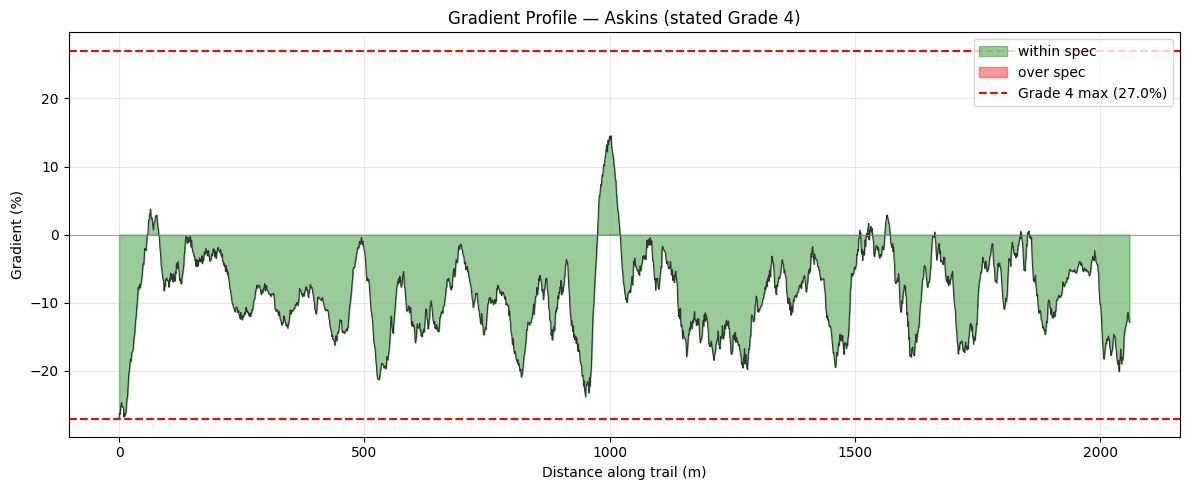

In [ ]:
# ── Gradient profile ───────────────────────────────────────────────

abs_limit = GRADIENT_ABS_MAX[stated_grade]
x = np.arange(len(smoothed_dense))
y = np.asarray(smoothed_dense)

fig, ax = plt.subplots(figsize=(12, 5))

# Draws the gradient profile in one go instead of 2,000 individual segments.
# This fixes the slow rendering problem that I was experiencing previously.
ax.fill_between(x, y, 0, where=np.abs(y) <= abs_limit, color="green", alpha=0.4,
                interpolate=True, label="within spec")
ax.fill_between(x, y, 0, where=np.abs(y) > abs_limit, color="red", alpha=0.4,
                interpolate=True, label="over spec")
ax.plot(x, y, linewidth=0.8, color="#333333")

ax.axhline(+abs_limit, color="red", linestyle="--", linewidth=1.5,
           label=f"Grade {stated_grade} max ({abs_limit}%)")
ax.axhline(-abs_limit, color="red", linestyle="--", linewidth=1.5)
ax.axhline(0, color="gray", linewidth=0.5)

ax.set_xlabel("Distance along trail (m)")
ax.set_ylabel("Gradient (%)")
ax.set_title(f"Gradient Profile — {trail_name} (stated Grade {stated_grade})")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()

png = os.path.join(OUTPUT_DIR, f"{trail_name}_gradient_profile.png")
plt.savefig(png, dpi=150)
print(f"Saved {png}")
plt.show()


In [26]:
# ── Folium map ─────────────────────────────────────────────────────

def gradient_color(g):
    g = abs(g)
    if g < 10: return "#00cc00"
    if g < 15: return "#ffff00"
    if g < 20: return "#ff8800"
    if g < 27: return "#ff4400"
    return "#cc0000"


def radius_color(r):
    if r > 5.0: return "#00cc00"
    if r > 4.0: return "#ffff00"
    if r > 2.5: return "#ff8800"
    if r > 2.0: return "#ff4400"
    return "#cc0000"


centre_lat = float(np.mean([lat for _, lat in points_wgs84_dense]))
centre_lon = float(np.mean([lon for lon, _ in points_wgs84_dense]))
m = folium.Map(location=[centre_lat, centre_lon], zoom_start=15)

gradient_layer = folium.FeatureGroup(name="Gradient", show=True)
offset = window // 2                    # smoothing trims the array; re-align to centre
aligned = points_wgs84_dense[offset: offset + len(smoothed_dense)]
for i in range(len(aligned) - 1):
    lon1, lat1 = aligned[i]
    lon2, lat2 = aligned[i + 1]
    folium.PolyLine(locations=[[lat1, lon1], [lat2, lon2]],
                    color=gradient_color(smoothed_dense[i]), weight=4,
                    tooltip=f"{i + offset} m — gradient {smoothed_dense[i]:+.1f}%"
                    ).add_to(gradient_layer)
gradient_layer.add_to(m)

radius_layer = folium.FeatureGroup(name="Turn radius", show=True)
for idx, r in corners:
    lon, lat = points_wgs84_dense[idx]
    folium.CircleMarker(location=[lat, lon], radius=10, color=radius_color(r),
                        fill=True, fill_opacity=0.9,
                        tooltip=f"{idx} m — turn radius {r:.1f} m").add_to(radius_layer)
radius_layer.add_to(m)

folium.Marker(location=[points_wgs84_dense[0][1], points_wgs84_dense[0][0]],
              tooltip="Start", icon=folium.Icon(color="green", icon="play")).add_to(m)
folium.Marker(location=[points_wgs84_dense[-1][1], points_wgs84_dense[-1][0]],
              tooltip="Finish", icon=folium.Icon(color="red", icon="stop")).add_to(m)
folium.LayerControl().add_to(m)

map_path = os.path.join(OUTPUT_DIR, f"{trail_name}_map.html")
m.save(map_path)
print(f"Saved {map_path}")
m


Saved ./output\Askins_map.html


In [ ]:
#Changed it so that I can view it in my browser rather than in the notebook. This is because the notebook is not very good at rendering 3D plots.
margin, grid_size = 150, 60

eastings  = [p[0] for p in points_nztm_dense]
northings = [p[1] for p in points_nztm_dense]

grid_e = np.linspace(min(eastings) - margin,  max(eastings) + margin,  grid_size)
grid_n = np.linspace(min(northings) - margin, max(northings) + margin, grid_size)
grid_pts = [to_wgs84.transform(e, n) for n in grid_n for e in grid_e]

TERRAIN_CACHE = os.path.join(CACHE_DIR, f"terrain_{trail_name}_{ELEVATION_LAYER}.json")
if os.path.exists(TERRAIN_CACHE):
    print("Loading terrain from cache...")
    with open(TERRAIN_CACHE) as f:
        grid_elevations = json.load(f)
else:
    print(f"Fetching {len(grid_pts)} terrain elevations...")
    with ThreadPoolExecutor(max_workers=20) as ex:
        grid_elevations = list(ex.map(fetch_elevation, grid_pts))
    with open(TERRAIN_CACHE, "w") as f:
        json.dump(grid_elevations, f)
    print(f"Cached to {TERRAIN_CACHE}")

print(f"{grid_elevations.count(None)} gaps (shown as holes, not walls)")

Z = np.array([e if e is not None else np.nan for e in grid_elevations],
             dtype=float).reshape(grid_size, grid_size)
E_grid, N_grid = np.meshgrid(grid_e, grid_n)

trail_z = [z + 2 for z in elevations_dense]          # lift 2 m to avoid z-fighting
pad = (len(elevations_dense) - len(smoothed_dense)) // 2
trail_colours = ([0] * pad + list(smoothed_dense)
                 + [0] * (len(elevations_dense) - len(smoothed_dense) - pad))

fig = go.Figure()
fig.add_trace(go.Surface(x=E_grid, y=N_grid, z=Z, colorscale="Earth",
                         opacity=0.95, showscale=False, name="Terrain"))
fig.add_trace(go.Scatter3d(
    x=eastings, y=northings, z=trail_z, mode="lines",
    line=dict(color=[abs(g) for g in trail_colours], colorscale="RdYlGn_r",
              cmin=0, cmax=27, width=6, colorbar=dict(title="Gradient %")),
    name=f"{trail_name} trail"))

if corners:
    fig.add_trace(go.Scatter3d(
        x=[points_nztm_dense[i][0] for i, _ in corners],
        y=[points_nztm_dense[i][1] for i, _ in corners],
        z=[elevations_dense[i] + 5 for i, _ in corners],
        mode="markers",
        marker=dict(size=8, color=[radius_color(r) for _, r in corners]),
        text=[f"{r:.1f} m radius" for _, r in corners],
        hoverinfo="text", name="Corners"))

fig.update_layout(title=f"{trail_name} — 3D terrain & trail",
                  scene=dict(xaxis_title="Easting (m)", yaxis_title="Northing (m)",
                             zaxis_title="Elevation (m)", aspectmode="data"),
                  height=800)

terrain_path = os.path.join(OUTPUT_DIR, f"{trail_name}_3d.html")
fig.write_html(terrain_path, auto_open=True)
print(f"Saved {terrain_path} (opening in browser)")


Loading terrain from cache...
0 gaps (shown as holes, not walls)
Saved ./output\Askins_3d.html (opening in browser)


In [ ]:
#Sideslope
# Measures the slope across the trail by sampling elevation either side of the centreline.

station_step = 5                        # metres between stations
offsets      = [-8, -6, -5, 5, 6, 8]    # metres perpendicular to centreline
dir_step     = 3                        # metres either side, for the bearing

stations, sample_pts = [], []
for i in range(dir_step, len(points_nztm_dense) - dir_step, station_step):
    stations.append(i)
    b = bearing(points_nztm_dense[i - dir_step], points_nztm_dense[i + dir_step]) + math.pi / 2
    cx, cy = points_nztm_dense[i]
    sample_pts += [(cx + d * math.cos(b), cy + d * math.sin(b)) for d in offsets]


def fetch_sideslope_point(p):
    return fetch_elevation(to_wgs84.transform(p[0], p[1]), layer=SIDESLOPE_LAYER)


SS_CACHE = os.path.join(CACHE_DIR, f"sideslope_{trail_name}_{SIDESLOPE_LAYER}_{line_hash}.json")
if os.path.exists(SS_CACHE):
    print("Loading cached sideslope samples...")
    with open(SS_CACHE) as f:
        ss_elevs = json.load(f)
else:
    print(f"Fetching {len(sample_pts)} sideslope samples from layer {SIDESLOPE_LAYER}...")
    with ThreadPoolExecutor(max_workers=20) as ex:
        ss_elevs = list(ex.map(fetch_sideslope_point, sample_pts))
    with open(SS_CACHE, "w") as f:
        json.dump(ss_elevs, f)
    print(f"Cached to {SS_CACHE}")


def sideslope_band(a):
    a = abs(a)
    if a < 5:  return "<5"
    if a < 15: return "5-15"
    if a < 30: return "15-30"
    if a < 45: return "30-45"
    return ">45"


n_off = len(offsets)
sideslopes = []
for k, i in enumerate(stations):
    z = ss_elevs[k * n_off:(k + 1) * n_off]
    pairs = [(o, e) for o, e in zip(offsets, z) if e is not None]
    if len(pairs) < 2:
        sideslopes.append((i, None, None))
        continue
    slope = np.polyfit([p[0] for p in pairs], [p[1] for p in pairs], 1)[0]
    angle = math.degrees(math.atan(slope))
    sideslopes.append((i, angle, sideslope_band(angle)))

valid = [a for _, a, _ in sideslopes if a is not None]
if not valid:
    print("No valid sideslope measurements — check layer coverage.")
else:
    print(f"\n{len(valid)} of {len(stations)} stations measured")
    print(f"Sideslope range    : {min(valid):+.1f}° to {max(valid):+.1f}°")
    print(f"Average |sideslope|: {np.mean(np.abs(valid)):.1f}°\n")
    for band in ["<5", "5-15", "15-30", "30-45", ">45"]:
        c = len([b for _, a, b in sideslopes if b == band])
        if c:
            print(f"  {band:>6}° : {c / len(valid) * 100:5.1f}% of trail")


Loading cached sideslope samples...

421 of 421 stations measured
Sideslope range    : -30.7° to +35.9°
Average |sideslope|: 20.4°

      <5° :   4.0% of trail
    5-15° :  15.0% of trail
   15-30° :  77.9% of trail
   30-45° :   3.1% of trail


Saved ./output\Askins_sideslope_profile.png


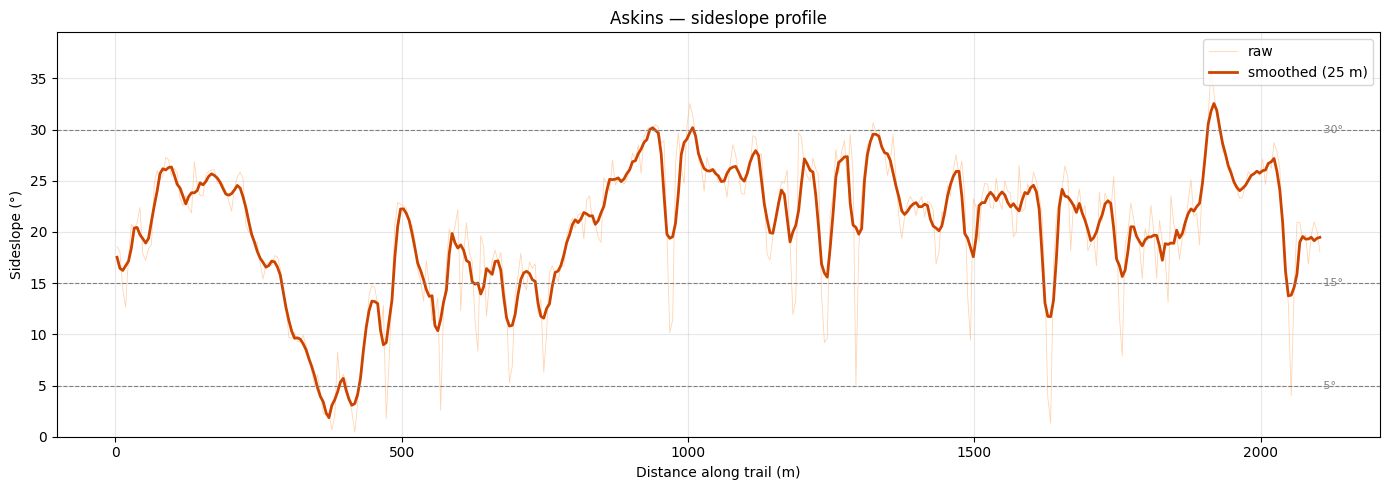

In [ ]:
# Sideslope profile.
#Plots the sideslope.

valid_ss = [(i, a) for i, a, _ in sideslopes if a is not None]
dist = [i for i, _ in valid_ss]
ang  = np.array([abs(a) for _, a in valid_ss])
ang_smooth = uniform_filter1d(ang, size=5)      # 5 stations x 5 m = 25 m

fig2, ax = plt.subplots(figsize=(14, 5))
ax.plot(dist, ang, color="#ffaa66", linewidth=0.6, alpha=0.5, label="raw")
ax.plot(dist, ang_smooth, color="#cc4400", linewidth=2, label="smoothed (25 m)")

ymax = max(float(ang.max()) * 1.1, 5.0)
for yv in (5, 15, 30, 45):        # only band lines inside the plotted range
    if yv <= ymax:
        ax.axhline(yv, color="gray", linestyle="--", linewidth=0.8)
        ax.text(dist[-1], yv, f" {yv}°", va="center", fontsize=8, color="gray")

ax.set_xlabel("Distance along trail (m)")
ax.set_ylabel("Sideslope (°)")
ax.set_title(f"{trail_name} — sideslope profile")
ax.set_ylim(0, ymax)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()

png2 = os.path.join(OUTPUT_DIR, f"{trail_name}_sideslope_profile.png")
plt.savefig(png2, dpi=150)
print(f"Saved {png2}")
plt.show()
